In [1]:
import numpy as np
from scipy.fft import fft, ifft, fftshift
import matplotlib.pyplot as plt
import pickle
%matplotlib inline

In [2]:
from pathlib import Path
path1 = Path("C:/Users/Scotty/M540/MATH-596-Mathematical-Data-Science/Lecture_Notes/data_set_1.pkl")
from pathlib import Path
path2 = Path("C:/Users/Scotty/M540/MATH-596-Mathematical-Data-Science/Lecture_Notes/data_set_2.pkl")

with open(path1, 'rb') as f:
    data_set_1 = pickle.load(f)

with open(path2, 'rb') as f:
    data_set_2 = pickle.load(f)

xvals1 = data_set_1[:, 0]
yvals1 = data_set_1[:, 1]

xvals2 = data_set_2[:, 0]
yvals2 = data_set_2[:, 1]

In [3]:
def xp_mat_maker(xvals, p):
    xp = np.ones((xvals.size, p+1))
    for jj in range(p):
        xp[:, jj+1] = xvals * xp[:, jj]
    return xp

In [4]:
def cos_mat_maker(xvals, freqs):
    cp = np.ones((xvals.size, len(freqs)))
    for jj, freq in enumerate(freqs):
        cp[:, jj] = np.cos(freq * xvals)
    return cp

In [5]:
def least_squares_solve(mat, yvals):
    u, s, vt = np.linalg.svd(mat, full_matrices=False)
    alpha = (vt.T @ np.diag(1./s) @ u.T) @ yvals.reshape(-1, 1)
    error = np.linalg.norm(mat @ alpha - yvals.reshape(-1, 1))
    return alpha, error 

## Homework 7 : Due 10/24/25 by 11:59 PM

**Problem 1**: Using a least-squares approach, find a polynomial model of the data set represented by `xvals1` and `yvals1`, i.e. find $p$ and corresponding $\alpha_{l}$ such that 

$$
y_{j} \approx \sum_{l=0}^{p}\alpha_{l}x_{j}^{l}
$$

Please explain how you arrived at your choice for $p$.  What is the condition number of your matrix $X_{p}$?  How does this value influence your choice of $p$? 

In [49]:
for p in range(1, 8):   
    xp = xp_mat_maker(xvals1, p)
    alpha, error = least_squares_solve(xp, yvals1)
    cond_number = np.linalg.cond(xp)
    
    print(f"P value: {p} \nCondition number: {cond_number} \nError: {error}\n")

P value: 1 
Condition number: 5.292719242672582 
Error: 165.01926053587005

P value: 2 
Condition number: 33.830433189836164 
Error: 148.73650851286507

P value: 3 
Condition number: 266.5756076781663 
Error: 148.72608059514775

P value: 4 
Condition number: 2274.3834613083945 
Error: 148.7200172309816

P value: 5 
Condition number: 20269.81528809531 
Error: 148.70948764720174

P value: 6 
Condition number: 185889.89594820456 
Error: 148.5938610437958

P value: 7 
Condition number: 1738886.2822227615 
Error: 148.219116727009



Looking at this output and the graph below, the most sensible choice is $p=2$. As values of $p$ get larger, the condition number increases exponentially for marginal decrease in error. While error does decrease faster the higher $p$ value, it's just not worth it as the condition number for $p=7$ is $\mathcal{O}(10^7)$. In fact, the pattern is apparent: for any $p \isin \mathbb{N}$, the error is $\mathcal{O}(10^p)$.

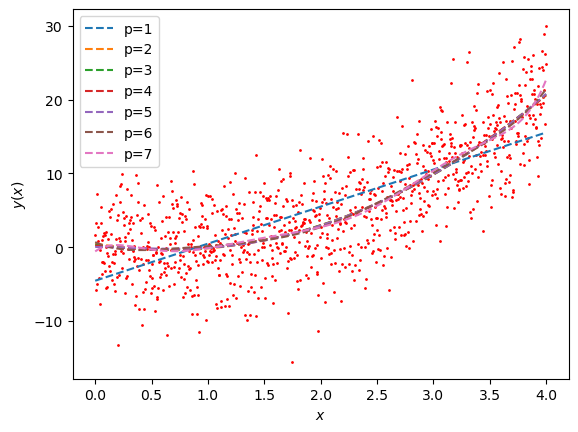

In [50]:
for p in range(1, 8):
    xp = xp_mat_maker(xvals1, p)
    alpha_p, _ = least_squares_solve(xp, yvals1)

    plt.plot(xvals1, xp @ alpha_p, label=f"p={p}", ls='--')

plt.scatter(xvals1, yvals1, color='r', s = 1.)

plt.xlabel(r"$x$")
plt.ylabel(r"$y(x)$")
plt.legend();

**Problem 2**: Using a least-squares approach, find a cos model of the data set reprsented by `xvals2` and `yvals2`.  In other finds, find $\alpha_{l}$ and $\omega_{l}$ such that

$$
y_{j} \approx \sum_{l=0}^{p}\alpha_{l}\cos(\omega_{l}x_{j}).
$$

To figure out the frequencies, you need to use an FFT.  Then you find the $\alpha_{l}$ terms using least-squares fitting.  Explain your choice of frequencies and the quality of fit that this gives you to your data set.  

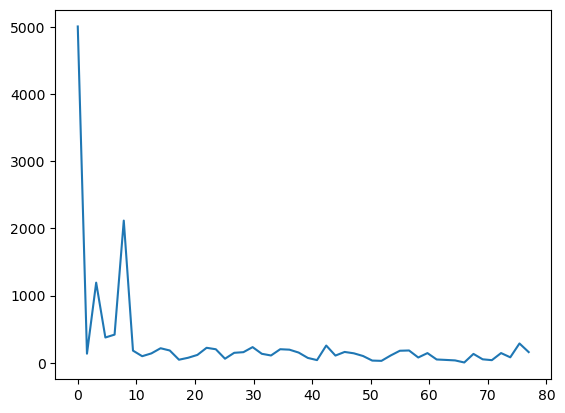

In [37]:
npts = yvals2.size
kvals = np.arange(int(npts/2)) * 2.*np.pi/xvals2[-1] # scale using period equal to max of xval
yfreq_plot = np.abs(fft(yvals2))[:int(npts/2)]

plt.plot(kvals[0:50], yfreq_plot[0:50]); # you might want to use slicing to zoom in on the frequencies you're most interested in

First 3 frequencies: Error = 186.5457501766478

First 5 frequencies: Error = 185.10194016883165

First 10 frequencies: Error = 159.25270911727915

First 50 frequencies: Error = 156.7843803065047



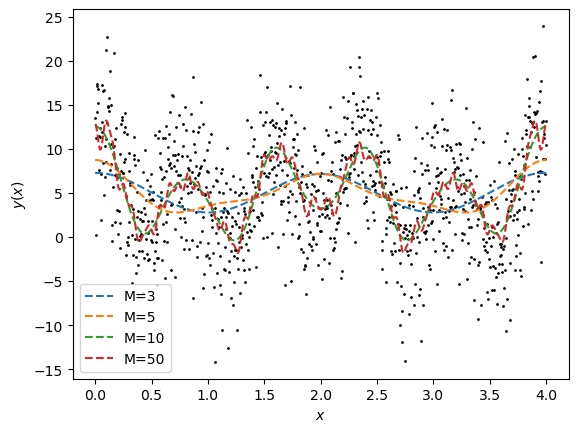

In [46]:
num_freqs = [3, 5, 10, 50]

for M in num_freqs:
    freqs = kvals[0:M]
    cp = cos_mat_maker(xvals2, freqs)
    alpha, error = least_squares_solve(cp, yvals2)

    print(f"First {M} frequencies: Error = {error}\n")
    plt.plot(xvals2, cp @ alpha, label=f"M={M}", ls='--')

plt.scatter(xvals2, yvals2, color='k', s = 1.)
plt.xlabel(r"$x$")
plt.ylabel(r"$y(x)$")
plt.legend();

Similar to the last problem, we see that the error only decreases slightly when including more frequencies, and that including too many starts to overfit the data. Based on these results and the FFT plot above, we notice that the first 10 frequencies are the largest and after that it is just basically noise. Since there are no frequencies that stand out later in the FFT plot, I think the best choice for M is 10. Had there been significant frequencies that were not included only at the start, it would have been important to include them, but in our case, `kvals[0:10]` fits our data well.

**Problem 3**: In $\mathbb{R}^{n}$ with a fixed vector ${\bf a}$ describe the following sets.  Illustrate your descriptions via examples in $n=2$ and $n=3$.  Remember that for real vectors 
$$
\left<{\bf a},{\bf x}\right>=\left<{\bf x},{\bf a}\right>={\bf x}^{T}{\bf a}={\bf a}^{T}{\bf x}.
$$
  * $\left\{{\bf x}\in \mathbb{R}^{n} : \left<{\bf a},{\bf x}\right>=0\right\}$
  * $\left\{{\bf x}\in \mathbb{R}^{n} : \left<{\bf a},{\bf x}\right>\geq 0\right\}$
  * $\left\{{\bf x}\in \mathbb{R}^{n} : \left<{\bf a},{\bf x}\right>= c, ~c > 0\right\}$
  * $\left\{{\bf x}\in \mathbb{R}^{n} : \left<{\bf a},{\bf x}\right> \geq c, ~c > 0\right\}$

* $\left\{{\bf x}\in \mathbb{R}^{n} : \left<{\bf a},{\bf x}\right>=0\right\}$: This describes the set of all vectors that are orthogonal to $\bf a$. It is a line or plane that passes perpendicularly (relative to $\bf a$) through the origin. $\bf x$ can fall anywhere on this line or plane. 

* $\left\{{\bf x}\in \mathbb{R}^{n} : \left<{\bf a},{\bf x}\right>\geq 0\right\}$: Since the inner product $\left<{\bf a},{\bf x}\right> = \|\bf a \| \|\bf x \|cos(\theta)$, and magnitudes of vectors are always nonnegative, then for the result to be greater than or equal to 0, then $cos(\theta) \geq 0$. Geometrically, this means $\bf a$ and $\bf x$ point in the same direction, and that the angle between them is $0 \leq \theta \leq 90$ degrees.

* $\left\{{\bf x}\in \mathbb{R}^{n} : \left<{\bf a},{\bf x}\right>= c, ~c > 0\right\}$: Thinking of the inner product as a projection, since $c$ is a fixed value, imagine again a line or plane that passes through $\bf a$ and is perpendicular to $\bf a$, passing through the point $\frac{c}{\|a\|}$. The set represents any vector $\bf x$ that ends on this line, which is another way to say that $proj_{a}(\bf x) = \frac{c}{\|a\|}$.

* $\left\{{\bf x}\in \mathbb{R}^{n} : \left<{\bf a},{\bf x}\right> \geq c, ~c > 0\right\}$: This set is the set of all vectors whose projection onto $\bf a$ is at least $\frac{c}{\|a\|}$. So it is the closed half-space on the same side of the line or plane $\left<{\bf a},{\bf x}\right>= c$ as the vector a.


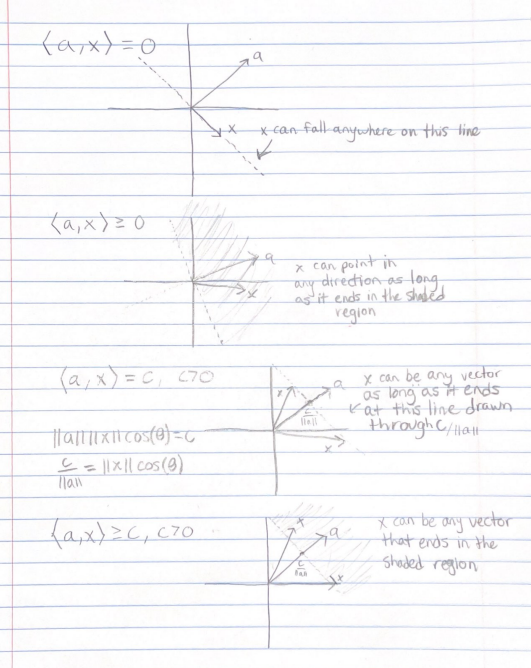

**Problem 4**: Following up on the previous problem, suppose I give you an underdetermined real matrix $A$ which is $k\times n$, $k<n$.  By the inequality $A{\bf x} \leq {\bf b}$, with ${\bf b}\in \mathbb{R}^{k}$, we mean this component-by component so that 
$$
(A{\bf x})_{j} \leq b_{j}, ~ j=1, \cdots, k.  
$$
How would you describe the shape formed by those ${\bf x}$ such that $A{\bf x} \leq {\bf b}$?  Illustrate your description in dimensions $n=2$ and $n=3$.  Are there cases when these inequalities don't make sense, which is to say, they cannot be satisfied?  

Each $(A{\bf x})_{j} \leq b_{j}$ starts to trace a shape in whatever dimension $k$ is. At the end, we are left with a very specific region formed by all points that satisfy the inequality simultaneously. 

**Problem 5**: A subset $E\subset \mathbb{R}^{n}$ is called _convex_ if for all ${\bf x}, {\bf y} \in E$, $t{\bf x} + (1-t){\bf y}\in E$ for $t\in[0,1]$.  This is equivalent to saying that a convex set is one that contains all of its line segments.  Show from the prior problem that $A{\bf x}\leq {\bf b}$ forms a convex set in $\mathbb{R}^{n}$.

Let $P = \left\{\bf {x} \in \mathbb{R}^{n} : A\bf {x} \leq b\right\}$.

If $x, y \in P$, then $A\bf {x} \leq b$ and $A\bf {y} \leq b$. Using the definition of convexity:

$A(t\bf {x} + (1 - t)\bf {y}) = tA\bf {x} + (1 - t)A\bf {y} \leq tb + (1 - t)b = b, t \in [0,1]$.

**Problem 6**: (Graduate/Challenge) Suppose we have the objective function 
$$
f({\bf x}) = \frac{1}{2}\left<H{\bf x},{\bf x}\right> + \left<{\bf x},{\bf v}\right> = \frac{1}{2}{\bf x}^{T}H{\bf x} + {\bf v}^{T}{\bf x}, 
$$
where $H$ is a real $n\times n$, positive definite matrix (that means symmetric with all positive eigenvalues, so that $H=O\Sigma^{2}O^{T}$, $OO^{T}=I$), and ${\bf v}\in\mathbb{R}^{n}$.  Find ${\bf x}_{\ast} = \text{arg min} f({\bf x})$ subject to the constraint $A{\bf x} \leq {\bf b}$, where $A$ is a real, underdetermined $k\times n$ matrix (i.e. k<n) of full rank.  

* Start by finding the critical points of the affiliated Lagrangian $L({\bf x}, \boldsymbol{\lambda})$ where
$$
L({\bf x}, {\bf \lambda}) = f({\bf x}) + \boldsymbol{\lambda}^{T}A{\bf x}, ~ \boldsymbol{\lambda} \in \mathbb{R}^{k}.
$$
Show that the critical ${\bf x}$, say ${\bf x}_{\ast}$ is given by ${\bf x}_{\ast} = -H^{-1}({\bf v} + A^{T}\boldsymbol{\lambda})$.  Note, the critical points are found by solving 
$$
\frac{\partial L}{\partial x_{j}} = 0, ~ j=1, \cdots, n,
$$
for all components.  The substitution ${\bf u} = O^{T}{\bf x}$ is still useful here.  

* Show that $f({\bf x}_{\ast}) = \frac{1}{2}\left(\boldsymbol{\lambda}^{T}A-{\bf v}^{T}\right)H^{-1}({\bf v} + A^{T}\boldsymbol{\lambda}) = -\frac{1}{2}\left<{\bf v}, H^{-1}{\bf v}\right> + \frac{1}{2}\left<\boldsymbol{\lambda}, AH^{-1}A^{T}\boldsymbol{\lambda} \right>$.  Note, for real vectors $\left<{\bf u}, {\bf v}\right> = \left<{\bf v}, {\bf u}\right>$, which will be useful in getting terms to disappear.  
* Show that the inequality constraint can be written as $AH^{-1}A^{T}\boldsymbol{\lambda} \geq -\left({\bf b} + AH^{-1}{\bf v}\right)$.
* Show that $AH^{-1}A^{T}$ is a positive definite $k\times k$ matrix and thus $\left<\boldsymbol{\lambda}, AH^{-1}A^{T}\boldsymbol{\lambda} \right> \gt 0$ for all $\boldsymbol{\lambda} \in \mathbb{R}^{k}$, $\boldsymbol{\lambda}\neq 0$.
* Find the solution for $k=1$, which means $AH^{-1}A^{T} = c > 0$ (you'll have to stare at that for a second to believe me).  